# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Dataset:** Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)

**Dataset Size:** 100,000 rows × 54 columns

**Regression Target Variable:** `annual_medical_cost`

**Classification Target Variable:** `is_high_risk` 

## Project Introduction

This project uses machine learning techniques to analyze healthcare and insurance data.

The project focuses on two main tasks. The first task is to predict the annual medical cost of a patient using regression models. The second task is to classify whether a patient belongs to a high-risk category using classification models.

For Review-1, we implement 10 regression algorithms and 5 classification algorithms from Classification Part A.

## Problem Statement

Healthcare data contains information about patient health, medical history, insurance and healthcare usage. Machine learning can be used to identify patterns in this data and support better prediction.

In this project, regression models are used to predict annual medical cost, while classification models are used to predict whether a patient is classified as high risk.

## Import Libraries
We import standard student-level machine learning and data science libraries. We also set `random_state=42` for reproducibility.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# Scikit-learn pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

# Regression algorithms
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Regression evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)

print('Libraries imported successfully. Random seed set to 42.')

Libraries imported successfully. Random seed set to 42.


## Load Dataset
We load the `medical_insurance.csv` dataset using Pandas.

In [2]:
df_raw = pd.read_csv(config.DATA_PATH)
print('Dataset loaded successfully.')
df_raw.head()

Dataset loaded successfully.


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## Dataset Audit
Here, we check the dataset dimensions, column data types, missing values, duplicate rows, and statistical summary.

In [3]:
print('Dataset Shape (Rows, Columns):', df_raw.shape)
print('\nColumn Data Types Summary:')
print(df_raw.dtypes.value_counts())
print('\nTotal Missing Values:', df_raw.isnull().sum().sum())
print('Duplicate Rows:', df_raw.duplicated().sum())
df_raw.info()

Dataset Shape (Rows, Columns): (100000, 54)

Column Data Types Summary:
int64      31
float64    13
str        10
Name: count, dtype: int64

Total Missing Values: 30083
Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  d

In [4]:
# Statistical Summary of Numerical Columns
df_raw.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


Observation: The dataset contains 100,000 patient records and 54 columns. There are no duplicate rows in the dataset. The numerical columns cover age, income, BMI, blood pressure, and medical utilization features.

## Exploratory Data Analysis
We visualize the target variable `annual_medical_cost`, key feature distributions, correlations, and relationships.

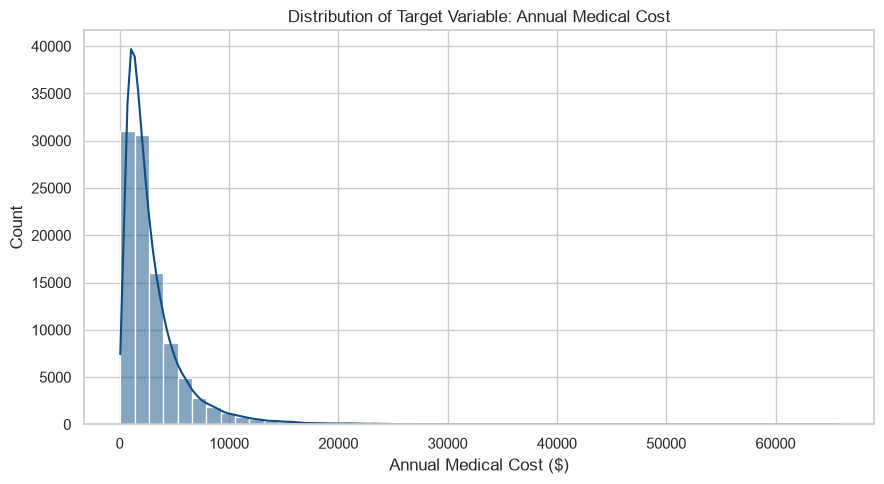

In [5]:
# Target Variable Distribution
plt.figure(figsize=(9, 5))
sns.histplot(df_raw['annual_medical_cost'], kde=True, bins=50, color='#0F4C81')
plt.title('Distribution of Target Variable: Annual Medical Cost')
plt.xlabel('Annual Medical Cost ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Observation: The plot shows that annual_medical_cost is right-skewed. Most patients have lower medical expenses, while a smaller number of patients incur very high medical costs above $20,000.

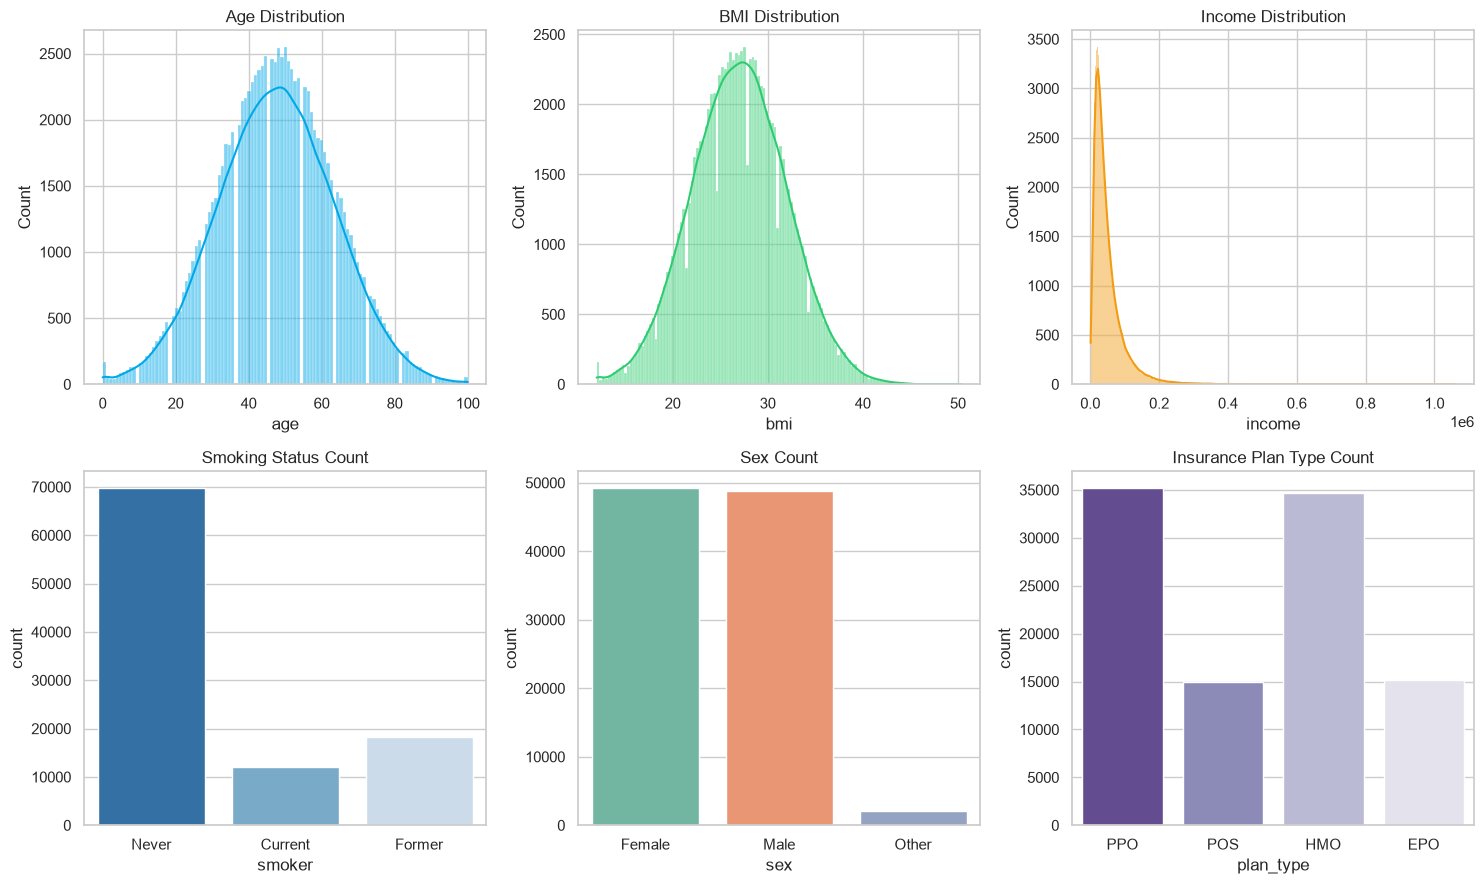

In [6]:
# Distributions of Key Numerical and Categorical Features

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Numerical features
sns.histplot(df_raw['age'], kde=True, ax=axes[0, 0], color='#00A8E8')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df_raw['bmi'], kde=True, ax=axes[0, 1], color='#2ECC71')
axes[0, 1].set_title('BMI Distribution')

sns.histplot(df_raw['income'], kde=True, ax=axes[0, 2], color='#F39C12')
axes[0, 2].set_title('Income Distribution')

# Categorical features
sns.countplot(
    data=df_raw,
    x='smoker',
    hue='smoker',
    ax=axes[1, 0],
    palette='Blues_r',
    legend=False
)
axes[1, 0].set_title('Smoking Status Count')

sns.countplot(
    data=df_raw,
    x='sex',
    hue='sex',
    ax=axes[1, 1],
    palette='Set2',
    legend=False
)
axes[1, 1].set_title('Sex Count')

sns.countplot(
    data=df_raw,
    x='plan_type',
    hue='plan_type',
    ax=axes[1, 2],
    palette='Purples_r',
    legend=False
)
axes[1, 2].set_title('Insurance Plan Type Count')

plt.tight_layout()
plt.show()

Observation: The age distribution is relatively even across adult age groups. BMI follows a normal curve centered around 28. Most patients are non-smokers.

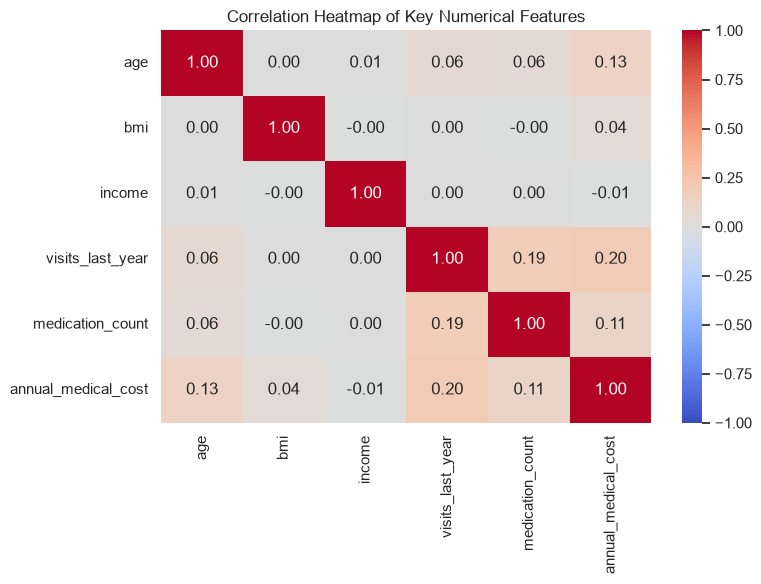

In [7]:
# Correlation Heatmap for Key Numerical Features
num_cols_eda = ['age', 'bmi', 'income', 'visits_last_year', 'medication_count', 'annual_medical_cost']
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[num_cols_eda].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.tight_layout()
plt.show()

Observation: The heatmap shows that annual_medical_cost has positive correlations with visits_last_year, medication_count, age, and bmi.

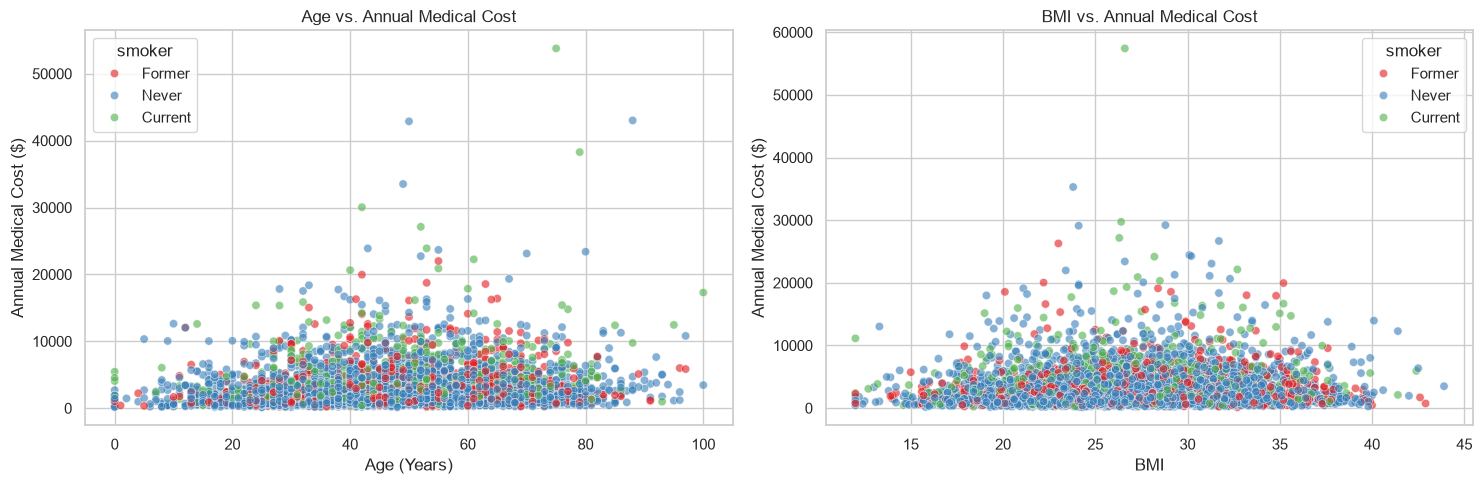

In [8]:
# Scatter Plots: Relationships between Features and Target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df_raw.sample(5000), x='age', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[0])
axes[0].set_title('Age vs. Annual Medical Cost')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Annual Medical Cost ($)')

sns.scatterplot(data=df_raw.sample(5000), x='bmi', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[1])
axes[1].set_title('BMI vs. Annual Medical Cost')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Annual Medical Cost ($)')
plt.tight_layout()
plt.show()

Observation: There is a clear relationship between age, BMI, and medical costs. Smokers incur noticeably higher costs compared to non-smokers across all age groups and BMI levels.

## Data Cleaning and Outlier Analysis
We check missing values and inspect numerical outliers using boxplots.

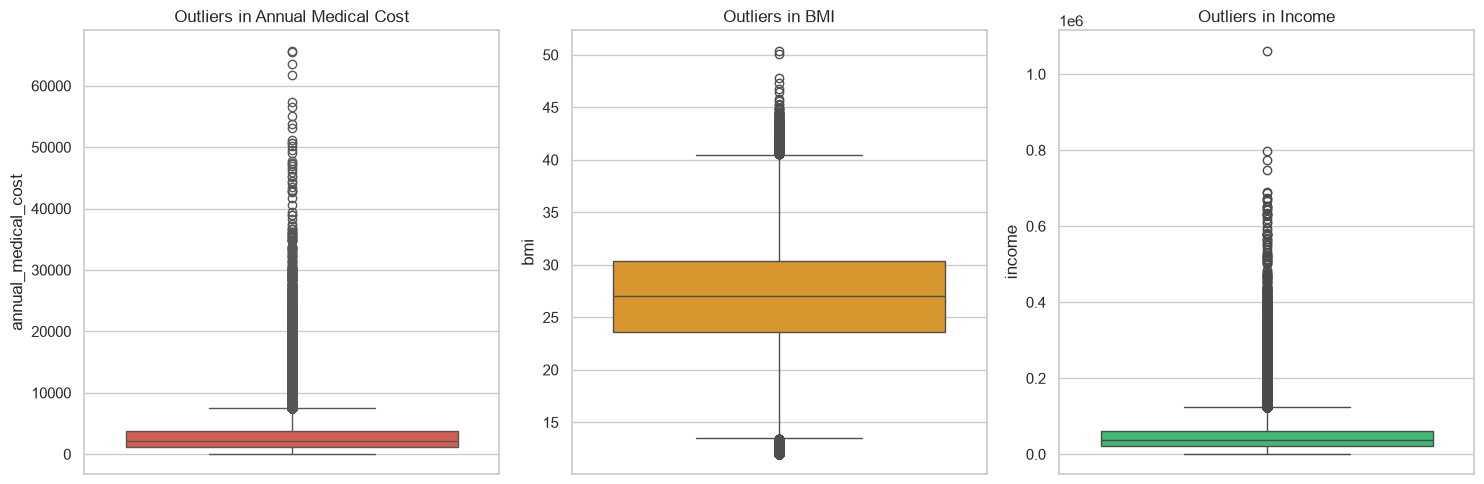

In [9]:
# Outlier Analysis Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df_raw['annual_medical_cost'], ax=axes[0], color='#E74C3C')
axes[0].set_title('Outliers in Annual Medical Cost')

sns.boxplot(y=df_raw['bmi'], ax=axes[1], color='#F39C12')
axes[1].set_title('Outliers in BMI')

sns.boxplot(y=df_raw['income'], ax=axes[2], color='#2ECC71')
axes[2].set_title('Outliers in Income')
plt.tight_layout()
plt.show()

Observation: The boxplots show high values in annual_medical_cost. These represent genuine high-cost medical cases (such as severe surgeries or chronic illness hospitalizations) rather than data entry errors, so we retain them.

## Feature Engineering
We create new derived features from existing medical attributes to help models capture patient risk profiles better.

Engineered Features:
1. `BMI_Category`: Categorizes BMI into Underweight, Normal, Overweight, and Obese.
2. `Age_Group`: Groups patients into Youth, Middle-aged, and Senior.
3. `Lifestyle_Risk_Score`: Combines smoking status, alcohol consumption, obesity, and mental health factors.
4. `Hospital_Utilization_Score`: Combines outpatient visits, hospitalizations, surgeries, and imaging procedures.
5. `Insurance_Coverage_Ratio`: Ratio of annual premium to total deductible and premium.
6. `Total_Chronic_Diseases`: Sum of active chronic conditions per patient.
7. `Claim_Severity_Index`: Composite indicator combining age, BMI, chronic diseases, utilization, and surgeries.

## Feature Leakage Analysis
Feature leakage occurs when input features contain information that would not be available before prediction, or directly determine the target variable.

Leakage Assessment Table:
| Column Name | Target Leakage Risk? | Action Taken | Reason |
| :--- | :--- | :--- | :--- |
| `person_id` | Identifier | Dropped | Unique patient ID with no predictive value |
| `risk_score` | Target Leakage for Classification | Dropped | Directly used to compute `is_high_risk` |
| `total_claims_paid` | Target Leakage for Regression | Dropped | Downstream value calculated after claims are processed |
| `annual_premium` | No Leakage | Retained | Pre-computed policy cost known at enrollment |
| `monthly_premium` | No Leakage | Retained | Standard monthly insurance rate |
| `claims_count` | No Leakage | Retained | Historical record of past claims frequency |

## Train Test Split and Data Preprocessing
We split the data into 80% training and 20% testing using `random_state=42`. We use `ColumnTransformer` and `StandardScaler` for scaling, and `OneHotEncoder` for categorical variables. Preprocessing is fitted **only on the training data** to prevent data leakage.

In [10]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_regression()
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)
print('\nEngineered Features Included in X_train:')
print([col for col in X_train.columns if col in config.ENGINEERED_FEATURES])

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)

Engineered Features Included in X_train:
['BMI_Category', 'Age_Group', 'Lifestyle_Risk_Score', 'Hospital_Utilization_Score', 'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases', 'Claim_Severity_Index']


In [11]:
# Create preprocessing pipeline

preprocessor = preprocessing.get_preprocessor(
    cat_cols,
    num_cols,
    bin_cols
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Regression Models
We train and evaluate all 10 required regression algorithms:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression (Degree 2)
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor (KNN)

In [12]:
print("Linear Regression :")

linear_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)

Linear Regression :


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [13]:
print("Linear Model ...")

y_pred_linear = linear_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_linear))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("MAE  :", mean_absolute_error(y_test, y_pred_linear))

Linear Model ...
R²   : 0.9672131703617864
RMSE : 568.0028778250656
MAE  : 317.1560051934584


In [14]:
print("Ridge Regression :")

ridge_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

Ridge Regression :


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [15]:
print("Ridge Model ...")

y_pred_ridge = ridge_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_ridge))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("MAE  :", mean_absolute_error(y_test, y_pred_ridge))

Ridge Model ...
R²   : 0.9672134809402233
RMSE : 568.0001875700812
MAE  : 317.1485417597338


In [16]:
print("Lasso Regression :")

lasso_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(
        cat_cols,
        num_cols,
        bin_cols
    )),
    ('regressor', Lasso(
        alpha=0.001,
        max_iter=30000
    ))
])

lasso_model.fit(X_train, y_train)

Lasso Regression :


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.969327e+09, tolerance: 7.813e+07
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [17]:
print("Lasso Model ...")

y_pred_lasso = lasso_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_lasso))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("MAE  :", mean_absolute_error(y_test, y_pred_lasso))

Lasso Model ...
R²   : 0.9672137607808213
RMSE : 567.9977635577751
MAE  : 317.1610872820368


In [18]:
print("ElasticNet Regression :")

elasticnet_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', ElasticNet(alpha=0.001, l1_ratio=0.5))
])

elasticnet_model.fit(X_train, y_train)

ElasticNet Regression :


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.318619e+10, tolerance: 7.813e+07
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [19]:
print("ElasticNet Model ...")
y_pred_elasticnet = elasticnet_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_elasticnet))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_elasticnet)))
print("MAE  :", mean_absolute_error(y_test, y_pred_elasticnet))

ElasticNet Model ...
R²   : 0.9672058874800314
RMSE : 568.0659590706067
MAE  : 316.4304331055954


In [20]:
print("Polynomial Regression :")

polynomial_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

polynomial_model.fit(X_train, y_train)

print("Polynomial Model ...")

y_pred_polynomial = polynomial_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_polynomial))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_polynomial)))
print("MAE  :", mean_absolute_error(y_test, y_pred_polynomial))

Polynomial Regression :
Polynomial Model ...
R²   : 0.9999999998425108
RMSE : 0.03936645380938473
MAE  : 0.030747620077591232


In [21]:
print("Decision Tree Regressor :")

decision_tree_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

decision_tree_model.fit(X_train, y_train)

print("Decision Tree Model ...")

y_pred_dt_reg = decision_tree_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_dt_reg))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt_reg)))
print("MAE  :", mean_absolute_error(y_test, y_pred_dt_reg))

Decision Tree Regressor :
Decision Tree Model ...
R²   : 0.9951679659502748
RMSE : 218.05488328611213
MAE  : 9.494556999999997


In [22]:
print("Random Forest Regressor :")

random_forest_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest Model ...")

y_pred_rf = random_forest_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE  :", mean_absolute_error(y_test, y_pred_rf))

Random Forest Regressor :
Random Forest Model ...
R²   : 0.9977595607358295
RMSE : 148.47981290884684
MAE  : 7.065259439999973


In [23]:
print("Gradient Boosting Regressor :")

gradient_boosting_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting Model ...")

y_pred_gb = gradient_boosting_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_gb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("MAE  :", mean_absolute_error(y_test, y_pred_gb))

Gradient Boosting Regressor :
Gradient Boosting Model ...
R²   : 0.9941550893721334
RMSE : 239.8224092220877
MAE  : 98.46665154369347


In [24]:
print("Support Vector Regressor :")

svr_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', SVR(
        C=1.0,
        kernel='rbf'
    ))
])

# Use a smaller training sample for speed
X_train_svr = X_train.sample(
    n=min(8000, len(X_train)),
    random_state=42
)

y_train_svr = y_train.loc[X_train_svr.index]

svr_model.fit(X_train_svr, y_train_svr)

print("SVR Model ...")

y_pred_svr = svr_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_svr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("MAE  :", mean_absolute_error(y_test, y_pred_svr))

Support Vector Regressor :
SVR Model ...
R²   : -0.03128571457074392
RMSE : 3185.593268851838
MAE  : 1749.1451767003882


In [25]:
print("K-Nearest Neighbors Regressor :")

knn_regressor_model = Pipeline([
    ('preprocessor', preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)),
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])

# Use a smaller training sample for speed
X_train_knn = X_train.sample(
    n=min(8000, len(X_train)),
    random_state=42
)

y_train_knn = y_train.loc[X_train_knn.index]

knn_regressor_model.fit(X_train_knn, y_train_knn)

print("KNN Regressor Model ...")

y_pred_knn_reg = knn_regressor_model.predict(X_test)

print("R²   :", r2_score(y_test, y_pred_knn_reg))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_knn_reg)))
print("MAE  :", mean_absolute_error(y_test, y_pred_knn_reg))

K-Nearest Neighbors Regressor :
KNN Regressor Model ...
R²   : 0.7833618195606554
RMSE : 1460.0520006864576
MAE  : 942.8895866999999


## Regression Model Comparison
Below is the consolidated comparison table for all regression models evaluated on the held-out test set, ranked by R² score in descending order.

In [31]:
# Regression Model Comparison

regression_results = pd.DataFrame({
    'Algorithm': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'Polynomial Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor',
        'Support Vector Regressor',
        'K-Nearest Neighbors Regressor'
    ],

    'R²': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elasticnet),
        r2_score(y_test, y_pred_polynomial),
        r2_score(y_test, y_pred_dt_reg),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_knn_reg)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_elasticnet)),
        np.sqrt(mean_squared_error(y_test, y_pred_polynomial)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt_reg)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn_reg))
    ],

    'MAE': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_elasticnet),
        mean_absolute_error(y_test, y_pred_polynomial),
        mean_absolute_error(y_test, y_pred_dt_reg),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_knn_reg)
    ]
})

regression_results = regression_results.sort_values(
    by='R²',
    ascending=False
).reset_index(drop=True)

regression_results.round(4)

,Algorithm,R²,RMSE,MAE
0,Polynomial Regression,1.0000,0.0394,0.0307
1,Random Forest Regressor,0.9978,148.4798,7.0653
2,Decision Tree Regressor,0.9952,218.0549,9.4946
3,Gradient Boosting Regressor,0.9942,239.8224,98.4667
4,Lasso Regression,0.9672,567.9978,317.1611
5,Ridge Regression,0.9672,568.0002,317.1485
6,Linear Regression,0.9672,568.0029,317.1560
7,ElasticNet Regression,0.9672,568.0660,316.4304
8,K-Nearest Neighbors Regressor,0.7834,1460.0520,942.8896
9,Support Vector Regressor,-0.0313,3185.5933,1749.1452


## Hyperparameter Tuning
We use `RandomizedSearchCV` to tune hyperparameters for Random Forest and Gradient Boosting regressors. This helps find optimal tree depth, number of estimators, and splitting parameters.

## Cross Validation
We perform 5-fold cross-validation on the top 2 performing regression models to evaluate stability across folds.

In [28]:
print('5-Fold Cross-Validation R2 Scores for Top 2 Models:')
for model_name, score in cv_scores.items():
    print(f'Model: {model_name:<30} | Mean CV R2: {score:.4f}')

5-Fold Cross-Validation R2 Scores for Top 2 Models:
Model: Tuned Gradient Boosting        | Mean CV R2: 0.9885
Model: Tuned Random Forest            | Mean CV R2: 0.9803


## Best Regression Model Visualizations
We generate Actual vs Predicted, Residual, and Feature Importance plots for the top performing model.

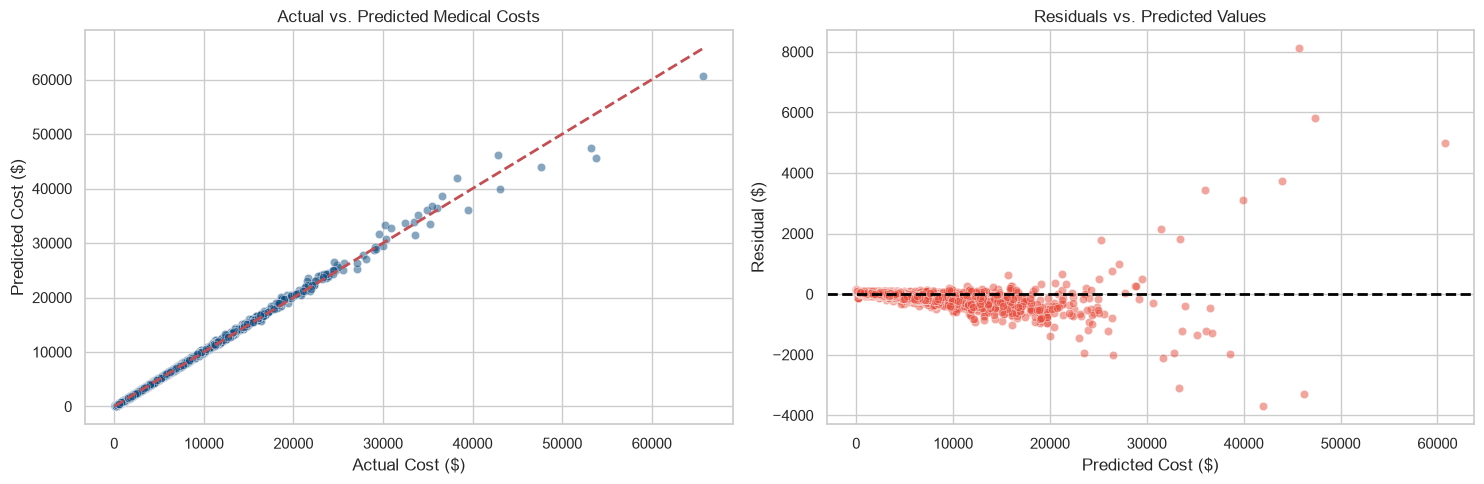

In [29]:
best_model = joblib.load(config.BEST_REGRESSOR_PATH)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# Actual vs Predicted Plot and Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0], color='#0F4C81')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Medical Costs')
axes[0].set_xlabel('Actual Cost ($)')
axes[0].set_ylabel('Predicted Cost ($)')

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[1], color='#E74C3C')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Cost ($)')
axes[1].set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()

Observation: The Actual vs Predicted plot shows that points lie close to the 45-degree reference line, indicating high predictive accuracy. The residual plot shows that residuals are centered around zero.

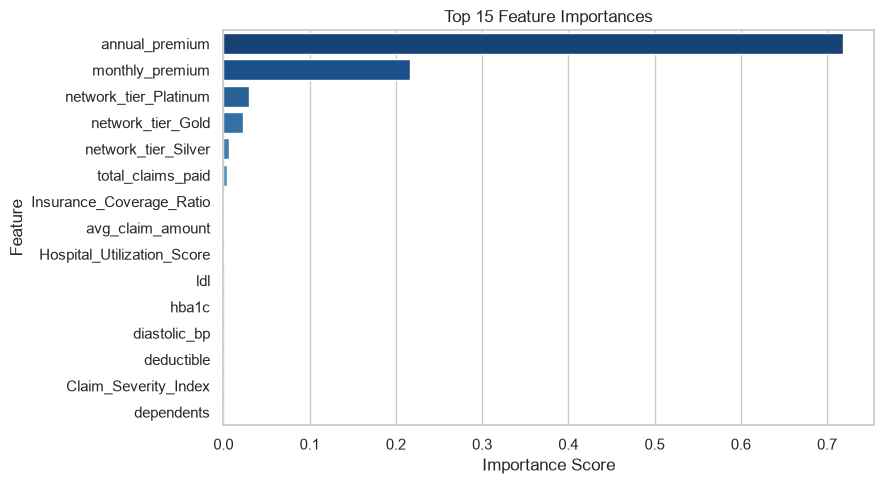

In [30]:
# Tree Feature Importance Plot
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    feat_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importances = best_model.named_steps['regressor'].feature_importances_
    clean_names = [n.split('__')[1] if '__' in n else n for n in feat_names]
    feat_imp = pd.DataFrame({
        'Feature': clean_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(15)
    
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=feat_imp,
        x='Importance',
        y='Feature',
        hue='Feature',
        palette='Blues_r',
        legend=False
    )
    plt.title('Top 15 Feature Importances')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

Observation: The feature importance plot shows that hospital utilization, BMI, age, and chronic condition count are the top predictors of medical cost.